In [1]:
import requests
import pandas as pd
import time

BASE_URL = "https://api.jikan.moe/v4"

def jikan_get(endpoint, params=None, sleep=1.2):
    """Simple Jikan API helper with polite delay."""
    time.sleep(sleep)
    r = requests.get(BASE_URL + endpoint, params=params, timeout=20)
    if r.status_code == 429:
        time.sleep(5)
        r = requests.get(BASE_URL + endpoint, params=params, timeout=20)
    r.raise_for_status()
    return r.json()

def get_top_manga_pages(pages=5):
    rows = []

    for page in range(1, pages + 1):
        print(f"Fetching top manga page {page}...")
        data = jikan_get("/top/manga", params={"page": page})

        for item in data["data"]:
            rows.append({
                "mal_id": item.get("mal_id"),
                "title": item.get("title"),
                "type": item.get("type"),
                "score": item.get("score"),
                "scored_by": item.get("scored_by"),
                "rank": item.get("rank"),
                "popularity": item.get("popularity"),
                "members": item.get("members"),
                "favorites": item.get("favorites"),
                "volumes": item.get("volumes"),
                "chapters": item.get("chapters"),
                "status": item.get("status"),
                "published_from": item.get("published", {}).get("from"),
                "published_to": item.get("published", {}).get("to"),
                "genres": ", ".join([g["name"] for g in item.get("genres", [])]),
                "url": item.get("url")
            })

    return pd.DataFrame(rows)

df = get_top_manga_pages(pages=5)
df.head()

Fetching top manga page 1...
Fetching top manga page 2...
Fetching top manga page 3...
Fetching top manga page 4...
Fetching top manga page 5...


,mal_id,title,type,score,scored_by,rank,popularity,members,favorites,volumes,chapters,status,published_from,published_to,genres,url
0,2,Berserk,Manga,9.46,400524,1.0,1,800408,138440,NaN,NaN,Publishing,1989-08-25T00:00:00+00:00,None,"Action, Adventure, Award Winning, Drama, Fanta...",https://myanimelist.net/manga/2/Berserk
1,1706,JoJo no Kimyou na Bouken Part 7: Steel Ball Run,Manga,9.34,202592,2.0,20,326673,52168,24.0,96.0,Finished,2004-01-19T00:00:00+00:00,2011-04-19T00:00:00+00:00,"Action, Adventure, Mystery, Supernatural",https://myanimelist.net/manga/1706/JoJo_no_Kim...
2,656,Vagabond,Manga,9.27,176628,3.0,12,461113,48992,37.0,327.0,On Hiatus,1998-09-03T00:00:00+00:00,2015-05-21T00:00:00+00:00,"Action, Adventure, Award Winning",https://myanimelist.net/manga/656/Vagabond
3,13,One Piece,Manga,9.21,422492,4.0,3,700653,126322,NaN,NaN,Publishing,1997-07-22T00:00:00+00:00,None,"Action, Adventure, Fantasy",https://myanimelist.net/manga/13/One_Piece
4,162032,Guimi Zhi Zhu,Novel,9.19,7750,5.0,907,24427,1990,18.0,366.0,Finished,2020-05-01T00:00:00+00:00,2023-08-01T00:00:00+00:00,"Action, Fantasy, Mystery, Suspense",https://myanimelist.net/manga/162032/Guimi_Zhi...


In [2]:
df.to_csv("jrl_003_manga_raw.csv", index=False)

In [3]:
df["hit"] = (df["members"] >= df["members"].quantile(0.75)).astype(int)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

model_df = df[["hit", "score", "scored_by", "volumes", "chapters", "favorites"]].dropna()

X = model_df[["score", "scored_by", "volumes", "chapters", "favorites"]]
y = model_df["hit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression())
])

pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
prob = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("AUC:", roc_auc_score(y_test, prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

AUC: 1.0


In [5]:
print(df.shape)

df[["members","favorites","scored_by"]].corr()

(125, 17)


,members,favorites,scored_by
members,1.000000,0.938042,0.977232
favorites,0.938042,1.000000,0.949306
scored_by,0.977232,0.949306,1.000000


In [6]:
model_df = df[["hit", "score", "volumes", "chapters"]].dropna()

X = model_df[["score", "volumes", "chapters"]]
y = model_df["hit"]

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Rebuild hit variable
df["hit"] = (df["members"] >= df["members"].quantile(0.75)).astype(int)

# Only structural variables
model_df = df[
    ["hit", "score", "volumes", "chapters"]
].dropna()

X = model_df[
    ["score", "volumes", "chapters"]
]

y = model_df["hit"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression())
])

pipe.fit(X_train, y_train)

pred = pipe.predict(X_test)
prob = pipe.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("AUC:", roc_auc_score(y_test, prob))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.75      0.60      0.67         5

    accuracy                           0.85        20
   macro avg       0.81      0.77      0.78        20
weighted avg       0.84      0.85      0.84        20

AUC: 0.9066666666666667


In [8]:
print(df[["score","volumes","chapters","members"]].describe())

           score    volumes    chapters        members
count  125.00000  82.000000   82.000000     125.000000
mean     8.77416  17.134146  166.902439  121485.352000
std      0.17791  13.691272  149.476090  145968.469548
min      8.57000   1.000000    8.000000    2607.000000
25%      8.64000   6.250000   56.750000   26205.000000
50%      8.71000  14.500000  128.500000   71211.000000
75%      8.86000  23.000000  229.250000  154638.000000
max      9.46000  77.000000  772.000000  800408.000000


In [9]:
df[["score","volumes","chapters","members"]].corr()

,score,volumes,chapters,members
score,1.000000,0.119827,0.102612,0.468571
volumes,0.119827,1.000000,0.809255,0.223265
chapters,0.102612,0.809255,1.000000,0.090942
members,0.468571,0.223265,0.090942,1.000000


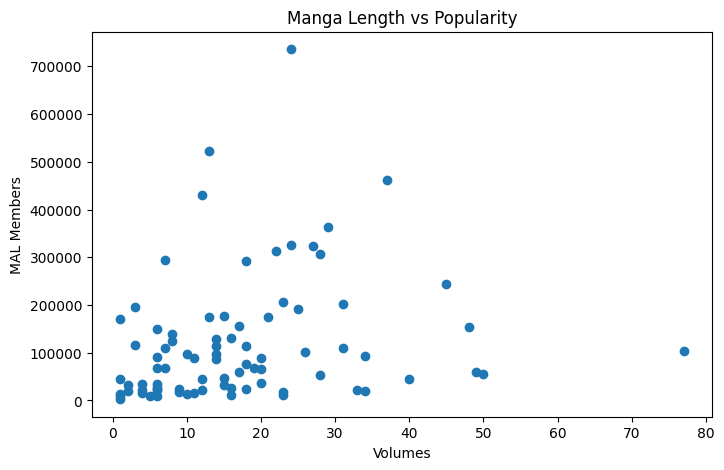

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["volumes"],
    df["members"]
)

plt.xlabel("Volumes")
plt.ylabel("MAL Members")
plt.title("Manga Length vs Popularity")

plt.show()

In [11]:
import pandas as pd
import numpy as np

features = ["score", "volumes", "chapters"]

coefs = pipe.named_steps["logit"].coef_[0]

coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values("coefficient", ascending=False)

coef_table

,feature,coefficient,odds_ratio
0,score,0.800442,2.226526
1,volumes,0.517791,1.678316
2,chapters,-0.067244,0.934967


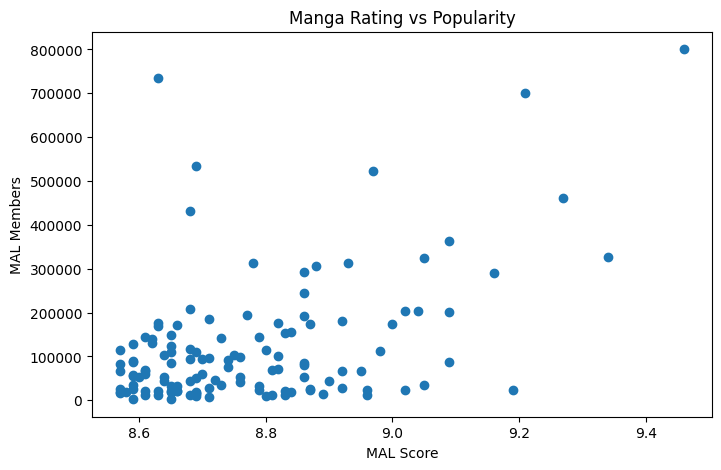

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["score"], df["members"])

plt.xlabel("MAL Score")
plt.ylabel("MAL Members")
plt.title("Manga Rating vs Popularity")

plt.show()

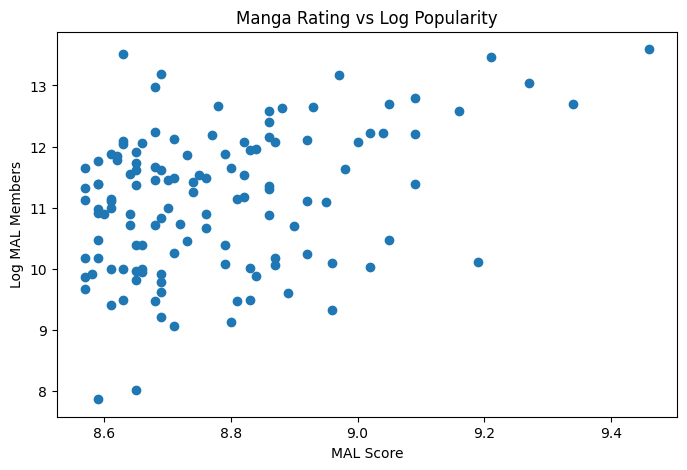

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(df["score"], np.log1p(df["members"]))

plt.xlabel("MAL Score")
plt.ylabel("Log MAL Members")
plt.title("Manga Rating vs Log Popularity")

plt.show()

In [14]:
import requests
import pandas as pd
import time

rows = []

for page in range(1, 21):  # ~500 manga
    print(page)

    r = requests.get(
        "https://api.jikan.moe/v4/manga",
        params={
            "page": page,
            "order_by": "members",
            "sort": "desc"
        }
    )

    data = r.json()["data"]

    for item in data:

        rows.append({
            "title": item.get("title"),
            "score": item.get("score"),
            "members": item.get("members"),
            "favorites": item.get("favorites"),
            "volumes": item.get("volumes"),
            "chapters": item.get("chapters"),
            "status": item.get("status")
        })

    time.sleep(1.2)

manga_df = pd.DataFrame(rows)

print(manga_df.shape)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
(500, 7)


In [15]:
manga_df.head()

,title,score,members,favorites,volumes,chapters,status
0,Berserk,9.46,800408,138440,NaN,NaN,Publishing
1,Chainsaw Man,8.63,735793,91626,24.0,232.0,Finished
2,One Piece,9.21,700653,126322,NaN,NaN,Publishing
3,Shingeki no Kyojin,8.56,694938,69887,34.0,141.0,Finished
4,Solo Leveling,8.56,620633,47208,NaN,201.0,Finished


In [16]:
manga_df.describe()

,score,members,favorites,volumes,chapters
count,500.000000,500.000000,500.000000,364.000000,372.000000
mean,8.046100,109189.496000,6258.500000,17.087912,143.161290
std,0.553653,102489.930474,12193.034219,12.080901,124.055008
min,6.040000,41410.000000,289.000000,1.000000,1.000000
25%,7.717500,52027.250000,1500.000000,10.000000,59.750000
50%,8.100000,72358.000000,2822.000000,15.000000,109.500000
75%,8.430000,122502.500000,5717.750000,23.000000,190.750000
max,9.460000,800408.000000,138440.000000,77.000000,709.000000


In [17]:
import numpy as np

df2 = manga_df.copy()

df2 = df2.sort_values("members", ascending=False)

df2["share"] = df2["members"] / df2["members"].sum()

df2["cum_share"] = df2["share"].cumsum()

print("Top 10 share:",
      df2.head(10)["share"].sum())

print("Top 25 share:",
      df2.head(25)["share"].sum())

print("Top 50 share:",
      df2.head(50)["share"].sum())

Top 10 share: 0.11346855195668273
Top 25 share: 0.2151101420964522
Top 50 share: 0.321704113370026


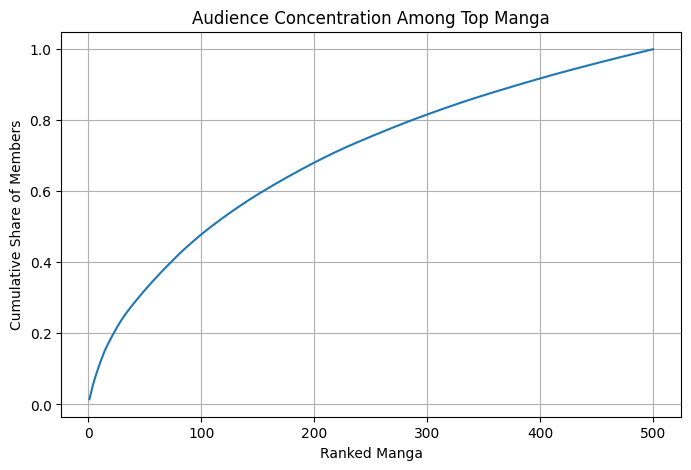

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(df2)+1),
    df2["cum_share"]
)

plt.xlabel("Ranked Manga")
plt.ylabel("Cumulative Share of Members")
plt.title("Audience Concentration Among Top Manga")

plt.grid(True)

plt.show()

In [20]:
import numpy as np
import statsmodels.api as sm

reg_df = manga_df[
    ["members","score","volumes","chapters"]
].dropna()

reg_df["log_members"] = np.log(reg_df["members"])

X = reg_df[
    ["score","volumes","chapters"]
]

X = sm.add_constant(X)

y = reg_df["log_members"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_members   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.208
Method:                 Least Squares   F-statistic:                     32.39
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           1.56e-18
Time:                        20:45:36   Log-Likelihood:                -299.50
No. Observations:                 360   AIC:                             607.0
Df Residuals:                     356   BIC:                             622.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.6869      0.460     16.698      0.0

In [21]:
import numpy as np
import statsmodels.api as sm

reg_df = manga_df[
    ["members","score","volumes","chapters","favorites"]
].dropna()

reg_df["log_members"] = np.log(reg_df["members"])

X = reg_df[
    ["score","volumes","chapters","favorites"]
]

X = sm.add_constant(X)

y = reg_df["log_members"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_members   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.633
Method:                 Least Squares   F-statistic:                     155.7
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           8.90e-77
Time:                        20:47:12   Log-Likelihood:                -160.56
No. Observations:                 360   AIC:                             331.1
Df Residuals:                     355   BIC:                             350.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.2902      0.339     30.395      0.0

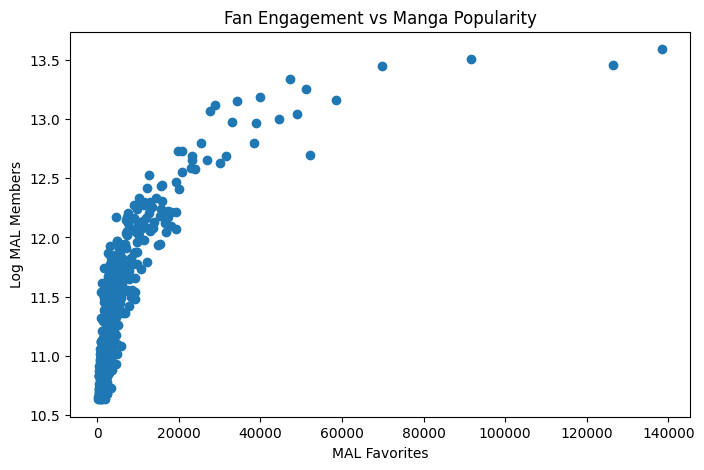

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.scatter(manga_df["favorites"], np.log(manga_df["members"]))

plt.xlabel("MAL Favorites")
plt.ylabel("Log MAL Members")
plt.title("Fan Engagement vs Manga Popularity")

plt.show()

In [23]:
import numpy as np
import statsmodels.api as sm

reg_df = manga_df[
    ["members","score","favorites"]
].dropna()

reg_df["log_members"] = np.log(reg_df["members"])
reg_df["log_favorites"] = np.log(reg_df["favorites"] + 1)

X = sm.add_constant(
    reg_df[["score","log_favorites"]]
)

y = reg_df["log_members"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_members   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     1572.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          1.27e-215
Time:                        20:51:38   Log-Likelihood:                 26.488
No. Observations:                 500   AIC:                            -46.98
Df Residuals:                     497   BIC:                            -34.33
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.8360      0.151     58.337

In [24]:
reg_df[["score", "log_favorites", "log_members"]].corr()

,score,log_favorites,log_members
score,1.000000,0.624862,0.393468
log_favorites,0.624862,1.000000,0.903098
log_members,0.393468,0.903098,1.000000
